# Tahap 1 Pengumpulan dan Persiapan Data

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Membaca data
baca = pd.read_csv("go_track_tracks.csv")
baca.head()
baca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163 entries, 0 to 162
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              163 non-null    int64  
 1   id_android      163 non-null    int64  
 2   speed           163 non-null    float64
 3   time            163 non-null    float64
 4   distance        163 non-null    float64
 5   rating          163 non-null    int64  
 6   rating_bus      163 non-null    int64  
 7   rating_weather  163 non-null    int64  
 8   car_or_bus      163 non-null    int64  
 9   linha           80 non-null     object 
dtypes: float64(3), int64(6), object(1)
memory usage: 12.9+ KB


Pada tahap ini, kita mengimpor pustaka yang dibutuhkan dan memuat dataset. Dari hasil baca.info(), dataset ini memiliki 163 baris dan 10 kolom. Kolom linha (yang berisi teks rute) memiliki banyak nilai kosong (NaN) yaitu hanya 80 baris yang terisi.

In [18]:
baca = baca.drop(["linha"], axis=1)

Karena kolom linha memiliki banyak nilai kosong dan datanya berbentuk teks yang tidak relevan secara numerik untuk jarak Euclidean pada algoritma K-Means, maka kolom tersebut dihapus.

# Tahap 2 Pemilihan Variabel dan Eksplorasi Visual

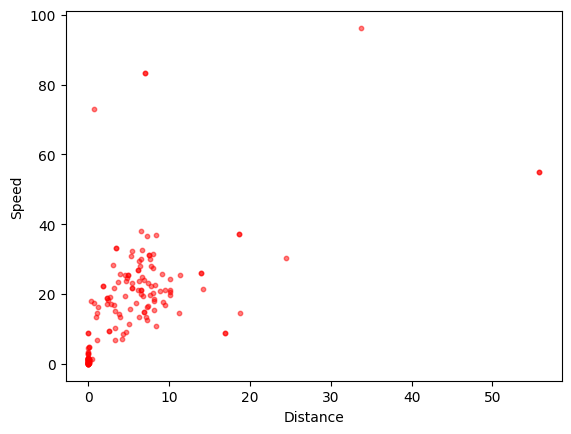

In [19]:
# Menentukan variabel yang akan diklusterkan
baca_x = baca.iloc[:, 1:3]

# Memvisualkan persebaran data
plt.scatter(baca.distance, baca.speed, s=10, c="red", marker="o", alpha=0.5)
plt.xlabel("Distance")
plt.ylabel("Speed")
plt.show()

Penjelasan & Hasil:

    Catatan Inkonsistensi: Pada modul Anda, baca.iloc[:, 1:3] mengambil kolom indeks 1 (id_android) dan indeks 2 (speed). Namun di bagian visualisasi awal, kode modul memplot variabel distance dan speed. Ini membingungkan karena data yang akan di-kluster dan data yang diplot berbeda.

    Gambar Sebaran Data: Plot di bawah ini adalah hasil dari variabel distance dan speed sesuai kode modul.

# Tahap 3 Normalisasi Data

In [20]:
x_array = np.array(baca_x) # Mengubah dataframe menjadi array

scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x_array)

Penjelasan & Hasil:
K-Means sangat sensitif terhadap skala data karena menghitung "jarak" (Euclidean distance). Variabel speed mungkin memiliki rentang angka belasan hingga puluhan, sedangkan variabel lain mungkin berskala satuan. Oleh karena itu, Min-Max Scaling digunakan untuk merapatkan semua nilai agar berada di rentang 0 hingga 1.

# Tahap 4: Membuat Model Klasifikasi (K-Means Clustering)

In [21]:
# Membuat model KMeans
kmeans = KMeans(n_clusters=3, random_state=42)

# Training model (KOREKSI: Seharusnya fit ke x_scaled, bukan baca)
kmeans.fit(x_scaled)

# Menambahkan hasil cluster ke dataframe asli
baca["kluster"] = kmeans.labels_
print(baca.head())

   id  id_android      speed      time  distance  rating  rating_bus  \
0   1           0  19.210586  0.138049     2.652       3           0   
1   2           0  30.848229  0.171485     5.290       3           0   
2   3           1  13.560101  0.067699     0.918       3           0   
3   4           1  19.766679  0.389544     7.700       3           0   
4   8           0  25.807401  0.154801     3.995       2           0   

   rating_weather  car_or_bus  kluster  
0               0           1        0  
1               0           1        0  
2               0           2        0  
3               0           2        0  
4               0           1        0  


Penjelasan & Hasil:

    Koreksi Krusial: Pada modul Anda, perintah training tertulis kmeans.fit(baca). Ini adalah kesalahan, karena algoritma akan mempelajari seluruh kolom (termasuk ID dan atribut lain yang tak diskalakan). Yang benar adalah melakukan fitting pada data yang sudah diseleksi dan dinormalisasi, yaitu x_scaled!

    Model kini membagi data menjadi 3 klaster (0, 1, dan 2) dan label tersebut disimpan di kolom baru bernama kluster.

# Tahap 5: Visualisasi Hasil Clustering

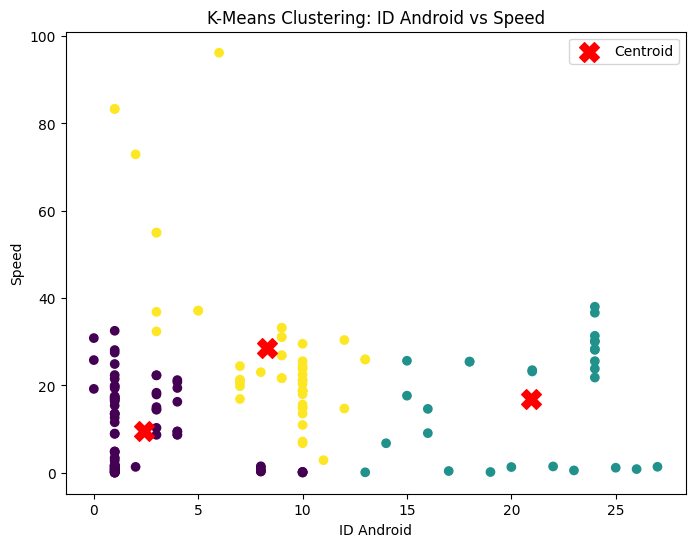

In [24]:
plt.figure(figsize=(8,6))

# Plot hasil clustering (kita pakai fitur id_android dan speed karena menggunakan baca_x iloc[:,1:3])
plt.scatter(baca['id_android'], baca['speed'], c=baca['kluster'], cmap='viridis')

# Plot Centroid (titik pusat tiap klaster)
plt.scatter(
    scaler.inverse_transform(kmeans.cluster_centers_)[:, 0], # Kembalikan skala centroid ke angka asli
    scaler.inverse_transform(kmeans.cluster_centers_)[:, 1],
    s=200, c='red', marker='X', label='Centroid'
)

plt.xlabel('ID Android')
plt.ylabel('Speed')
plt.title('K-Means Clustering: ID Android vs Speed')
plt.legend()
plt.show()

Penjelasan & Hasil:

    Koreksi Teks Aksis: Pada modul Anda, label X dan Y ditulis sebagai 'Frequency' dan 'Monetary'. Itu adalah istilah untuk analisis pelanggan (RFM Analysis) dan tidak ada hubungannya dengan dataset GPS Trajectory Anda. Saya telah mengubahnya menjadi ID Android dan Speed.

    Visualisasi: Hasil titik dengan berbagai warna merepresentasikan 3 klaster yang terbentuk. Titik "X" merah muda besar adalah Centroid (Pusat massa) dari masing-masing klaster.